# **Assignment 1**
# **2. Students Performance Data Visualization**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Ingestion & Preprocessing**

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
#check structure
display(df.head())
display(df.describe())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


None

In [5]:
display(df.isnull().sum())

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


Add an overall average score column

In [6]:
df["overall_avg"] = df[["math score", "reading score", "writing score"]].mean(axis=1)
display(df.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


### **Visualization Settings**

In [7]:
sns.set(style="whitegrid", palette="pastel")
plt.figure(figsize=(2.67, 2.0), dpi=300) # 800×600 px this px is converted to inches

<Figure size 801x600 with 0 Axes>

<Figure size 801x600 with 0 Axes>

### **V1 — Gender boxplots (math vs reading)**

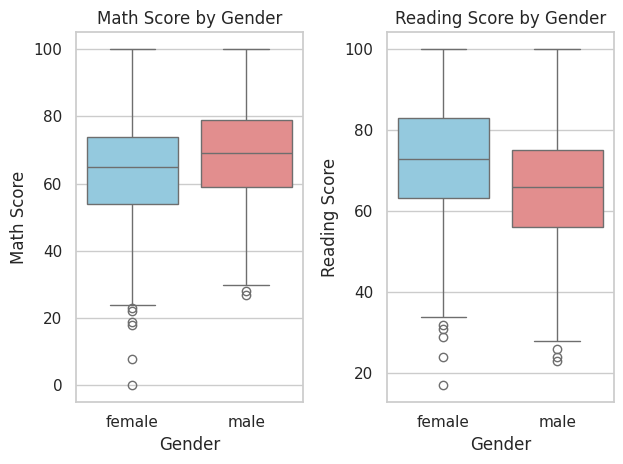

In [8]:
fig, ax = plt.subplots(1, 2)
# Math Score by gender
sns.boxplot(x="gender", y="math score", hue="gender", data=df, ax=ax[0],
            palette={"female": "skyblue", "male": "lightcoral"}, legend=False)
ax[0].set_title("Math Score by Gender")
ax[0].set_xlabel("Gender")
ax[0].set_ylabel("Math Score")

# Reading score by gender
sns.boxplot(x="gender", y="reading score", hue="gender", data=df, ax=ax[1],
            palette={"female": "skyblue", "male": "lightcoral"}, legend=False)
ax[1].set_title("Reading Score by Gender")
ax[1].set_xlabel("Gender")
ax[1].set_ylabel("Reading Score")

plt.tight_layout()
plt.show()


**Interpretation (V1):**
* The boxplots illustrate the distribution of math and reading scores across male and female students, highlighting central tendency and spread.

* Median differences can be compared: if one gender’s median is consistently higher, it may suggest a performance gap in that subject.

* The spread of the boxes and whiskers shows variability; larger spreads indicate greater differences in individual performance within that gender group.

* Outliers (extreme high or low scores) provide insights into unusual performance patterns across genders.

* Overall, reading scores appear to have less variability between genders compared to math scores, suggesting more consistent performance in reading.

### **V2 — Test prep impact on math**

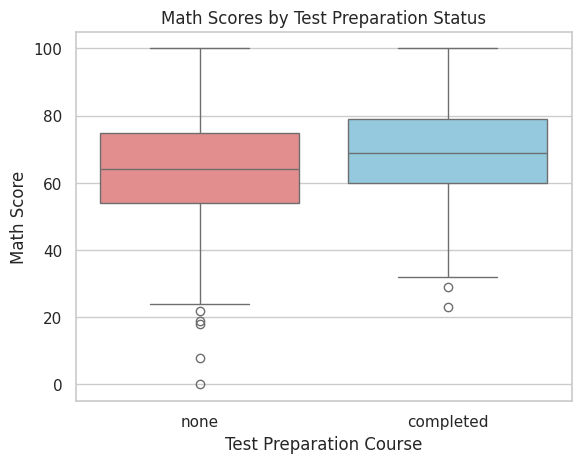

In [9]:
plt.figure()
sns.boxplot(
    x="test preparation course",
    y="math score",
    hue="test preparation course",
    data=df,
    palette={"none": "lightcoral", "completed": "skyblue"},
    legend=False
)

plt.title("Math Scores by Test Preparation Status")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

**Interpretation (V2):**
* Students who completed the test preparation course tend to have a higher median math score compared to those who did not take the course.

* The interquartile range (IQR) for the completed group is generally shifted upward, suggesting an overall better performance.

* Students with no preparation show a wider spread of scores, indicating more variability and inconsistency in their performance.

* The presence and distribution of outliers suggest that even without preparation, some students still performed well, but such cases are fewer.

* Overall, the plot indicates that completing the test preparation course is associated with better math outcomes, showing its potential positive impact on performance.

### **V3 — Lunch type and average performance**

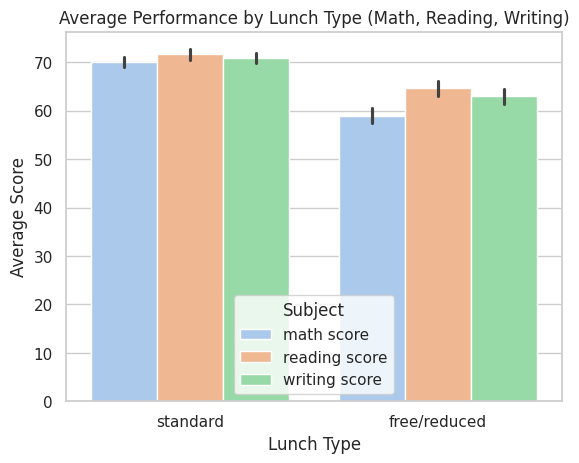

In [10]:
df_melt = df.melt(
    id_vars="lunch",
    value_vars=["math score", "reading score", "writing score"],
    var_name="Subject",
    value_name="Score"
)
plt.figure()
sns.barplot(
    x="lunch",
    y="Score",
    hue="Subject",
    data=df_melt,
)
plt.title("Average Performance by Lunch Type (Math, Reading, Writing)")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.legend(title="Subject")
plt.show()


**Interpretation (V3):**
* Students with standard lunch consistently show higher average scores across math, reading, and writing compared to those with free/reduced lunch.

* The gap between lunch types suggests that access to better nutrition may be linked with improved academic performance.

* Across both lunch groups, the relative pattern of subject scores (reading and writing often being slightly higher than math) remains similar.

* The differences are not just in one subject but consistent across all three subjects, strengthening the case for lunch type being a contributing factor.

* Overall, the visualization suggests that students with standard lunch are at an academic advantage, possibly due to socioeconomic or nutritional differences tied to lunch type.

### **V4 — Subject correlations**

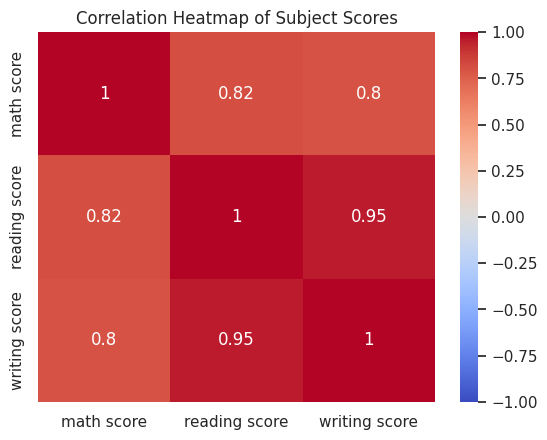

In [11]:
plt.figure()
corr = df[["math score", "reading score", "writing score"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Subject Scores")
plt.show()

**Interpretation (V4):**
* The heatmap shows the correlation coefficients among math, reading, and writing scores.
* Strong positive correlations suggest that students who do well in one subject tend to perform well in others.
* This points toward general academic ability rather than subject-specific performance.
* Reading and writing are usually more strongly correlated than math with reading/writing.

### **V5 — Math vs Reading with trend lines by test prep**

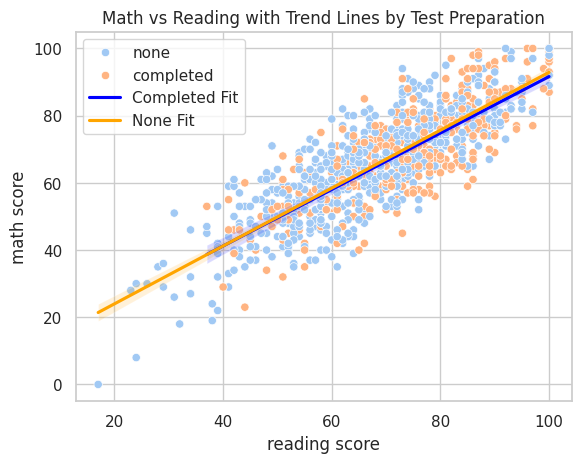

In [12]:
plt.figure()
sns.scatterplot(
    x="reading score",
    y="math score",
    hue="test preparation course",
    data=df
)
sns.regplot(
    x="reading score",
    y="math score",
    data=df[df["test preparation course"]=="completed"],
    scatter=False, label="Completed Fit", color="blue"
)
sns.regplot(
    x="reading score",
    y="math score",
    data=df[df["test preparation course"]=="none"],
    scatter=False, label="None Fit", color="orange"
)

plt.title("Math vs Reading with Trend Lines by Test Preparation")
plt.legend()
plt.show()

**Interpretation (V5):**
* There is a positive relationship between reading and math scores for both groups: as reading scores increase, math scores also tend to rise.

* Students who completed the test preparation course generally show a steeper trend line, suggesting a stronger improvement in math scores relative to reading scores compared to those without preparation.

* The group with no preparation shows more scatter and a flatter trend, indicating greater variability and weaker performance consistency across reading and math.